In [1]:
# CELL 1: Setup and Imports
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
import warnings

# Ignore benign warnings from statsmodels
warnings.filterwarnings("ignore")

print("Libraries imported successfully. Ready to load data.")

Libraries imported successfully. Ready to load data.


In [12]:
# CELL 2: Data Loading (Supports YFinance or CSV)
# ---------------------------------------------------------
# CONFIGURATION: Set USE_YFINANCE to False to use a CSV file.
# ---------------------------------------------------------
USE_YFINANCE = True
TICKER = "GC=F"        # Used if USE_YFINANCE is True
START_DATE = "2021-01-01"
END_DATE = "2026-08-30"

CSV_FILE_PATH = "stock_data.csv" # Used if USE_YFINANCE is False
DATE_COLUMN = "Date"             # Must match your CSV column name
PRICE_COLUMN = "Close"           # Must match your CSV column name

if USE_YFINANCE:
    print(f"--- Fetching {TICKER} data from Yahoo Finance ---")
    df = yf.download(TICKER, start=START_DATE, end=END_DATE)
    # yfinance sometimes returns a multi-index for columns if multiple tickers are passed,
    # but for one ticker, 'Close' is a standard series.
    if isinstance(df.columns, pd.MultiIndex):
        df = df.xs(TICKER, level=1, axis=1)
    ts_data = df['Close'].dropna()
else:
    print(f"--- Loading data from local CSV: {CSV_FILE_PATH} ---")
    df = pd.read_csv(CSV_FILE_PATH, parse_dates=[DATE_COLUMN], index_col=DATE_COLUMN)
    ts_data = df[PRICE_COLUMN].dropna()

print(f"Data loaded successfully! Number of observations: {len(ts_data)}")

[*********************100%***********************]  1 of 1 completed

--- Fetching GC=F data from Yahoo Finance ---
Data loaded successfully! Number of observations: 1423


In [13]:
# CELL 3: Define the Testing Workflow Function
def perform_stationarity_tests(timeseries, test_name="Raw Data"):
    print(f"\n{'='*50}")
    print(f"--- STEP 2 & 3: RUNNING TESTS ON: {test_name} ---")
    print(f"{'='*50}")

    # 1. ADF Test
    adf_result = adfuller(timeseries, autolag='AIC')
    adf_pvalue = adf_result[1]

    # 2. KPSS Test (regression='ct' checks for trend-stationarity)
    kpss_result = kpss(timeseries, regression='ct', nlags="auto")
    kpss_pvalue = kpss_result[1]

    print("\n[ TEST RESULTS ]")
    print(f"ADF p-value:  {adf_pvalue:.4f}")
    print(f"KPSS p-value: {kpss_pvalue:.4f}")

    print("\n[ STEP 4: COMBINED EVALUATION & EXPLANATION ]")

    # Evaluation Logic
    # Standard significance level is 0.05 (5%)
    adf_stationary = adf_pvalue < 0.05    # Rejects H0 (Unit Root) -> Stationary
    kpss_stationary = kpss_pvalue >= 0.05 # Fails to reject H0 (Trend-Stationary) -> Stationary

    if not adf_stationary and not kpss_stationary:
        print("Verdict: NON-STATIONARY (Unit Root Present)")
        print("Explanation: The ADF test failed to reject the null hypothesis of a unit root, AND the KPSS test rejected its null hypothesis of stationarity.")
        print("Action Required: You MUST transform this data (e.g., take the First Difference) before using it in econometric models like ARMA.")
        is_stationary = False

    elif adf_stationary and kpss_stationary:
        print("Verdict: STATIONARY (No Unit Root)")
        print("Explanation: Both tests agree. The series is stationary around a constant or a deterministic trend.")
        print("Action Required: No further differencing needed. You can proceed directly to econometric modeling (Step 7).")
        is_stationary = True

    elif not adf_stationary and kpss_stationary:
        print("Verdict: TREND-STATIONARY")
        print("Explanation: The ADF test detects a unit root, but KPSS says it is stationary around a trend.")
        print("Action Required: The data needs to be detrended (e.g., by subtracting a fitted trend line) rather than differenced.")
        is_stationary = False

    elif adf_stationary and not kpss_stationary:
        print("Verdict: DIFFERENCE-STATIONARY")
        print("Explanation: The series is stationary only after differencing, but strict level stationarity isn't fully confirmed by both.")
        print("Action Required: Differencing is recommended to strictly remove the unit root behavior.")
        is_stationary = False

    return is_stationary

--- STEP 1: VISUAL CHECK ---


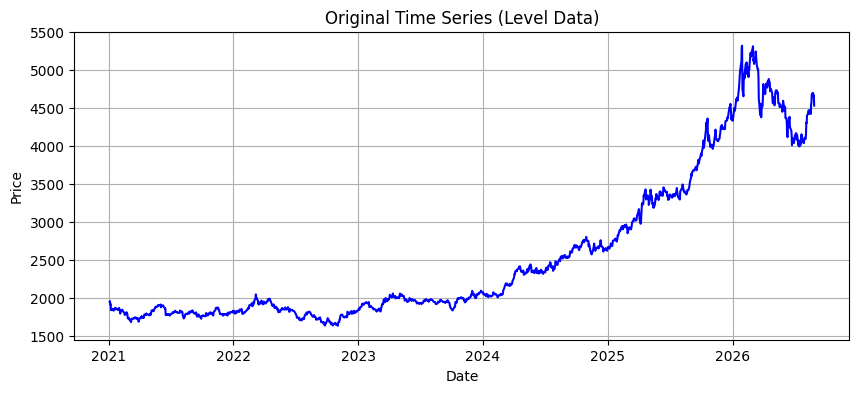

Instruction: Look at the plot above. Does it drift upward or downward? If yes, it is likely non-stationary.

--- STEP 2 & 3: RUNNING TESTS ON: Original Price Series ---

[ TEST RESULTS ]
ADF p-value:  0.9904
KPSS p-value: 0.0100

[ STEP 4: COMBINED EVALUATION & EXPLANATION ]
Verdict: NON-STATIONARY (Unit Root Present)
Explanation: The ADF test failed to reject the null hypothesis of a unit root, AND the KPSS test rejected its null hypothesis of stationarity.
Action Required: You MUST transform this data (e.g., take the First Difference) before using it in econometric models like ARMA.


In [14]:
# CELL 4: Step 1 - Visual Check & Initial Tests
print("--- STEP 1: VISUAL CHECK ---")
plt.figure(figsize=(10, 4))
plt.plot(ts_data, color='blue')
plt.title("Original Time Series (Level Data)")
plt.ylabel("Price")
plt.xlabel("Date")
plt.grid(True)
plt.show()
print("Instruction: Look at the plot above. Does it drift upward or downward? If yes, it is likely non-stationary.")

# Run the tests on the original data
data_is_stationary = perform_stationarity_tests(ts_data, test_name="Original Price Series")


--- STEP 5: TRANSFORM THE DATA ---
Action: Applying first difference (Subtracting yesterday's price from today's price)...

--- VISUAL CHECK OF DIFFERENCED DATA ---


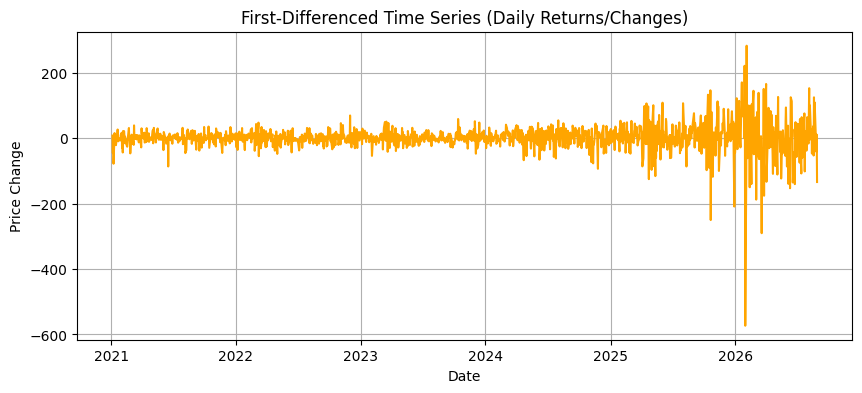

Instruction: The data should now look like random noise oscillating around zero, with no clear long-term trend.

--- STEP 2 & 3: RUNNING TESTS ON: First-Differenced Series ---

[ TEST RESULTS ]
ADF p-value:  0.0000
KPSS p-value: 0.1000

[ STEP 4: COMBINED EVALUATION & EXPLANATION ]
Verdict: STATIONARY (No Unit Root)
Explanation: Both tests agree. The series is stationary around a constant or a deterministic trend.
Action Required: No further differencing needed. You can proceed directly to econometric modeling (Step 7).

--- STEP 7: PROCEED TO MODELING ---
Once you achieve a 'STATIONARY' verdict, you can feed that specific data (usually the differenced data) into your AR, MA, ARMA, or ARIMA models.


In [15]:
# CELL 5: Step 5 & 6 - Transform (Difference) and Re-Test
if not data_is_stationary:
    print("\n--- STEP 5: TRANSFORM THE DATA ---")
    print("Action: Applying first difference (Subtracting yesterday's price from today's price)...")

    # Calculate first difference and drop the resulting NaN in the first row
    differenced_data = ts_data.diff().dropna()

    print("\n--- VISUAL CHECK OF DIFFERENCED DATA ---")
    plt.figure(figsize=(10, 4))
    plt.plot(differenced_data, color='orange')
    plt.title("First-Differenced Time Series (Daily Returns/Changes)")
    plt.ylabel("Price Change")
    plt.xlabel("Date")
    plt.grid(True)
    plt.show()
    print("Instruction: The data should now look like random noise oscillating around zero, with no clear long-term trend.")

    # Step 6: Re-test
    perform_stationarity_tests(differenced_data, test_name="First-Differenced Series")
else:
    print("\nData is already stationary. Skipping differencing step.")

print("\n--- STEP 7: PROCEED TO MODELING ---")
print("Once you achieve a 'STATIONARY' verdict, you can feed that specific data (usually the differenced data) into your AR, MA, ARMA, or ARIMA models.")